# Model Evaluation & Feature Importance

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve, auc)
import shap

In [ ]:
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
ART_DIR = Path('../artifacts')

In [20]:
fe = pd.read_parquet(ART_DIR / 'cert_engineered_features.parquet')
fe.shape

(1000, 35)

In [21]:
feature_cols = json.load(open(ART_DIR / 'model_feature_list.json'))
len(feature_cols)

32

In [22]:
X = fe[feature_cols].fillna(0)
y = fe['consensus_loose'].astype(int)
X.shape, int(y.sum())

((1000, 32), 90)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
X_train.shape, X_test.shape


((700, 32), (300, 32))

## Cross-validation

A single split can flatter or punish a model by luck. We run stratified 5-fold CV and report mean ± std for each metric. Stratification keeps the 9% positive rate in every fold. Linear/kernel models are scaled inside the loop; tree models are not.


In [24]:
def cv_scores(model, X_df, y_ser, scale):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rows = []
    for tr, va in skf.split(X_df, y_ser):
        Xtr, Xva = X_df.iloc[tr], X_df.iloc[va]
        ytr, yva = y_ser.iloc[tr], y_ser.iloc[va]
        if scale:
            sc = StandardScaler().fit(Xtr)
            Xtr, Xva = sc.transform(Xtr), sc.transform(Xva)
        model.fit(Xtr, ytr)
        p = model.predict_proba(Xva)[:, 1]
        pred = (p > 0.5).astype(int)
        rows.append([accuracy_score(yva, pred), precision_score(yva, pred, zero_division=0),
                     recall_score(yva, pred, zero_division=0), f1_score(yva, pred, zero_division=0),
                     roc_auc_score(yva, p)])
    arr = np.array(rows)
    return arr.mean(0), arr.std(0)


In [25]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
cv_models = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), True),
    'SVM': (SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42), True),
    'Random Forest': (RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42), False),
    'XGBoost': (XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                              scale_pos_weight=spw, eval_metric='logloss', random_state=42), False),
}
list(cv_models)


['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost']

In [26]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
cv_mean, cv_std = {}, {}
for name, (m, sc) in cv_models.items():
    mu, sd = cv_scores(m, X, y, sc)
    cv_mean[name], cv_std[name] = mu, sd
cv_table = pd.DataFrame(cv_mean, index=metrics).T
cv_table.round(3)


,accuracy,precision,recall,f1,auc
Logistic Regression,0.882,0.421,0.767,0.539,0.884
SVM,0.941,0.683,0.678,0.672,0.959
Random Forest,0.949,0.910,0.489,0.623,0.946
XGBoost,0.952,0.779,0.656,0.707,0.947


In [27]:
cv_std_table = pd.DataFrame(cv_std, index=metrics).T
cv_std_table.round(3)


,accuracy,precision,recall,f1,auc
Logistic Regression,0.030,0.076,0.155,0.096,0.062
SVM,0.008,0.067,0.096,0.046,0.017
Random Forest,0.011,0.083,0.129,0.112,0.019
XGBoost,0.006,0.029,0.096,0.056,0.027


**Read:** Across folds, SVM again has the best mean AUC and Random Forest the best precision, while Logistic Regression keeps the highest recall. The std columns show the minority-class metrics (precision, recall, F1) are the volatile ones — their fold-to-fold swing is large because a handful of anomalies land in each validation fold. AUC, by contrast, is stable, so it is the most reliable single number for ranking models here.

## ROC and Precision–Recall curves

With 9% positives, ROC can look optimistic; the PR curve is the stricter test because its baseline is the positive rate, not 0.5. We fit the three sklearn baselines on the training split and plot both on the test set.

In [28]:
curve_models = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), True),
    'SVM': (SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42), True),
    'Random Forest': (RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42), False),
}
probs = {}
for name, (m, sc) in curve_models.items():
    m.fit(X_train_s if sc else X_train, y_train)
    probs[name] = m.predict_proba(X_test_s if sc else X_test)[:, 1]
list(probs)


['Logistic Regression', 'SVM', 'Random Forest']

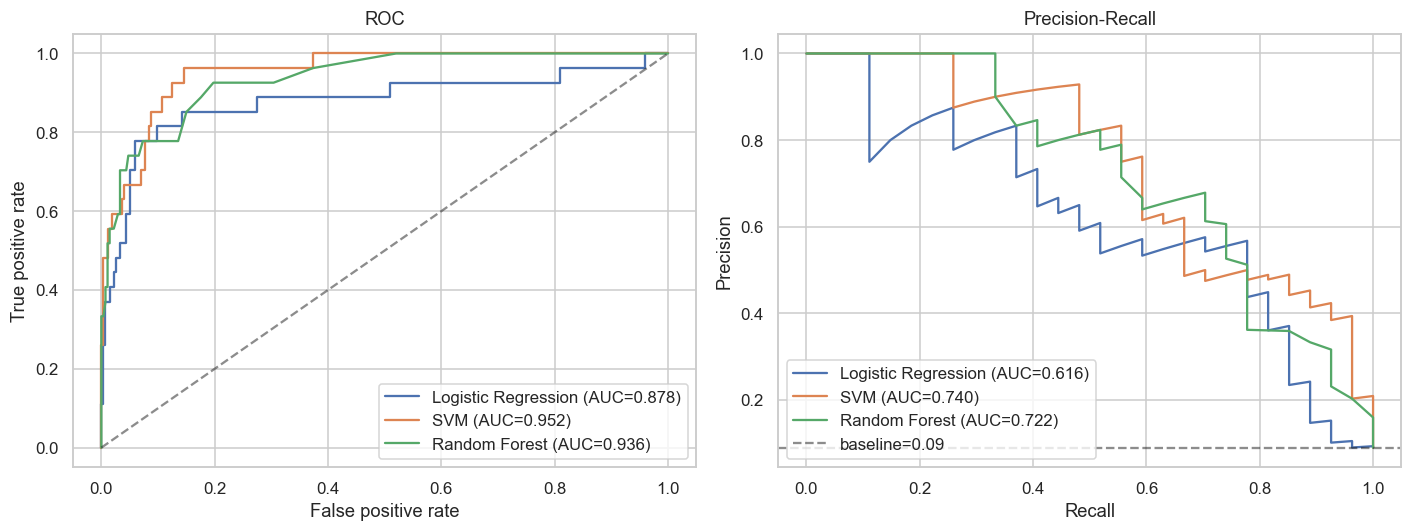

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, p in probs.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC'); axes[0].legend()
for name, p in probs.items():
    pr, rc, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rc, pr, label=f'{name} (AUC={auc(rc, pr):.3f})')
axes[1].axhline(y_test.mean(), color='k', ls='--', alpha=0.5, label=f'baseline={y_test.mean():.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall'); axes[1].legend()
plt.tight_layout()
plt.show()


**Read:** All three ROC curves sit well above the diagonal, but the PR curves reveal the operational reality — precision falls off as we push for higher recall. SVM holds the best precision–recall trade-off. The gap between the rosy ROC and the sober PR view is the quantitative case for tuning the decision threshold rather than trusting 0.5, which we take up in Week 8.

## Feature importance

We read importance two ways. Random Forest impurity importance captures non-linear contribution; Logistic Regression coefficient magnitude (on scaled inputs) captures signed linear influence. Agreement across methods raises our confidence in a feature.

In [30]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
rf_imp.head(12).round(4)


weekend_logon_ratio        0.0816
total_logons               0.0752
total_device_activities    0.0666
logon_intensity            0.0648
behavior_cluster           0.0639
weekend_logons             0.0626
device_intensity           0.0542
N                          0.0512
std_logon_hour             0.0406
activity_anomaly_score     0.0363
avg_logon_hour             0.0321
unique_files               0.0316
dtype: float64

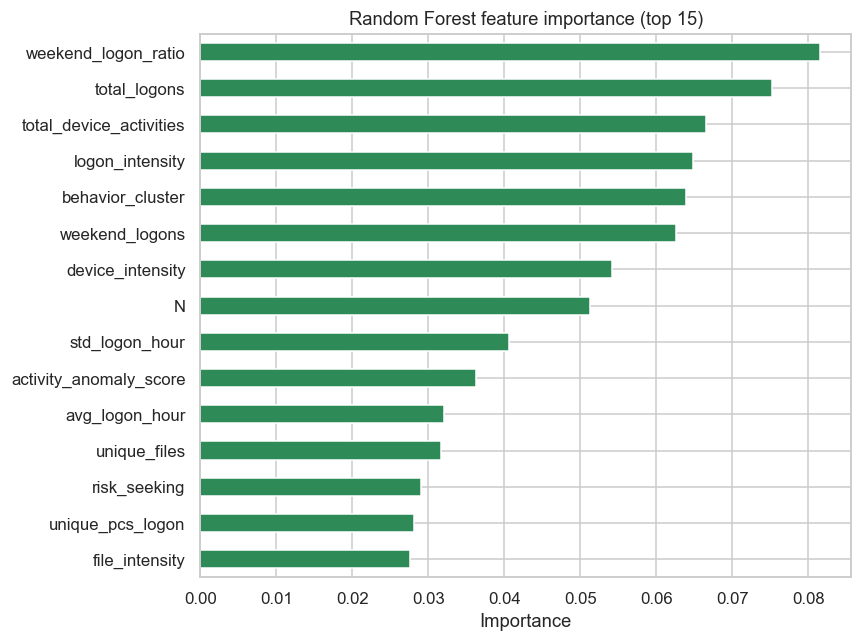

In [31]:
plt.figure(figsize=(8, 6))
rf_imp.head(15).iloc[::-1].plot.barh(color='seagreen')
plt.title('Random Forest feature importance (top 15)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


In [32]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
lr_coef = pd.Series(np.abs(lr.coef_[0]), index=feature_cols).sort_values(ascending=False)
lr_coef.head(12).round(3)


E                                 1.442
after_hours_logons                1.343
conscientiousness_extraversion    1.325
C                                 1.206
weekend_logon_ratio               1.140
after_hours_device                1.094
unique_pcs_logon                  0.934
activity_anomaly_score            0.918
avg_file_hour                     0.879
after_hours_device_ratio          0.826
total_device_activities           0.815
device_intensity                  0.815
dtype: float64

**Read:** Both views highlight the same behavioural axes — behaviour-cluster membership, activity intensity, after-hours/weekend ratios, and logon-time variability sit at the top. Psychometric traits contribute but rank lower. That the tree and the linear model agree on the leading features is reassuring: the signal is in off-schedule, high-intensity behaviour, exactly the documented insider-threat indicators.

## SHAP analysis

Importance says *how much* a feature matters; SHAP says *which direction* and *for whom*. We explain the Random Forest on a sample of the test set with TreeExplainer.

In [33]:
sample = X_test.sample(n=min(100, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(sample)
sv = shap_values[..., 1] if getattr(shap_values, 'ndim', 2) == 3 else shap_values
np.shape(sv)


(100, 32)

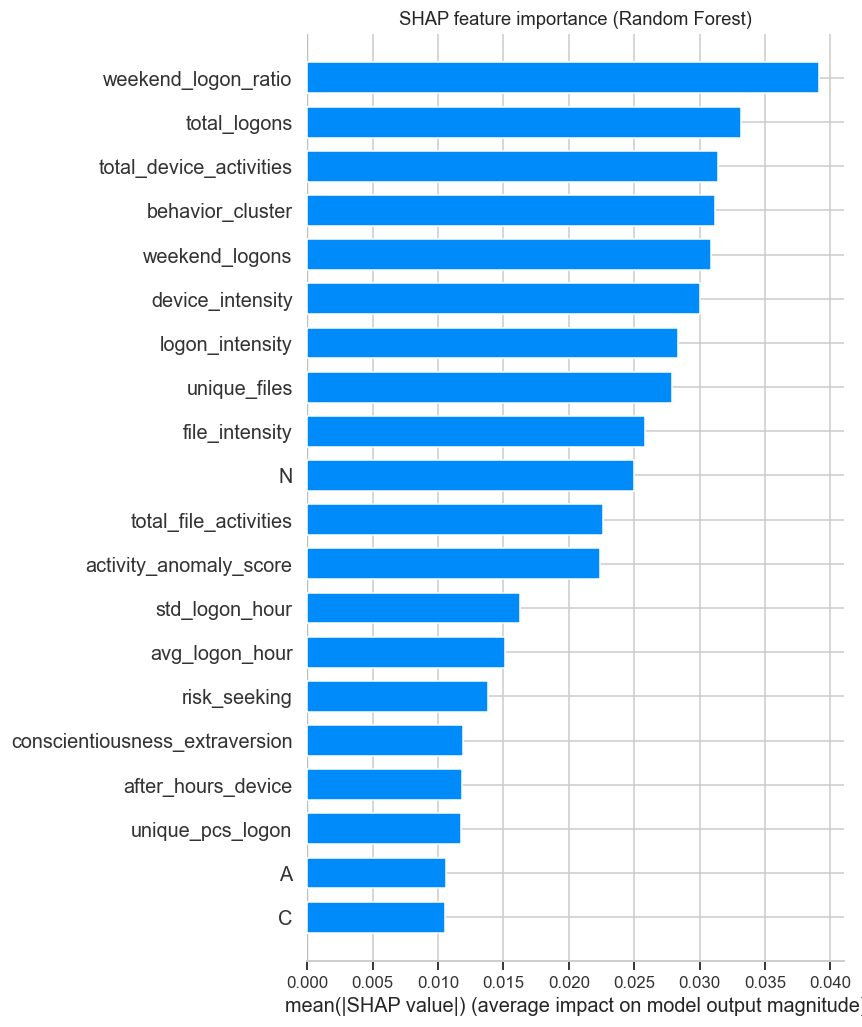

In [34]:
shap.summary_plot(sv, sample, plot_type='bar', show=False)
plt.title('SHAP feature importance (Random Forest)')
plt.tight_layout()
plt.show()


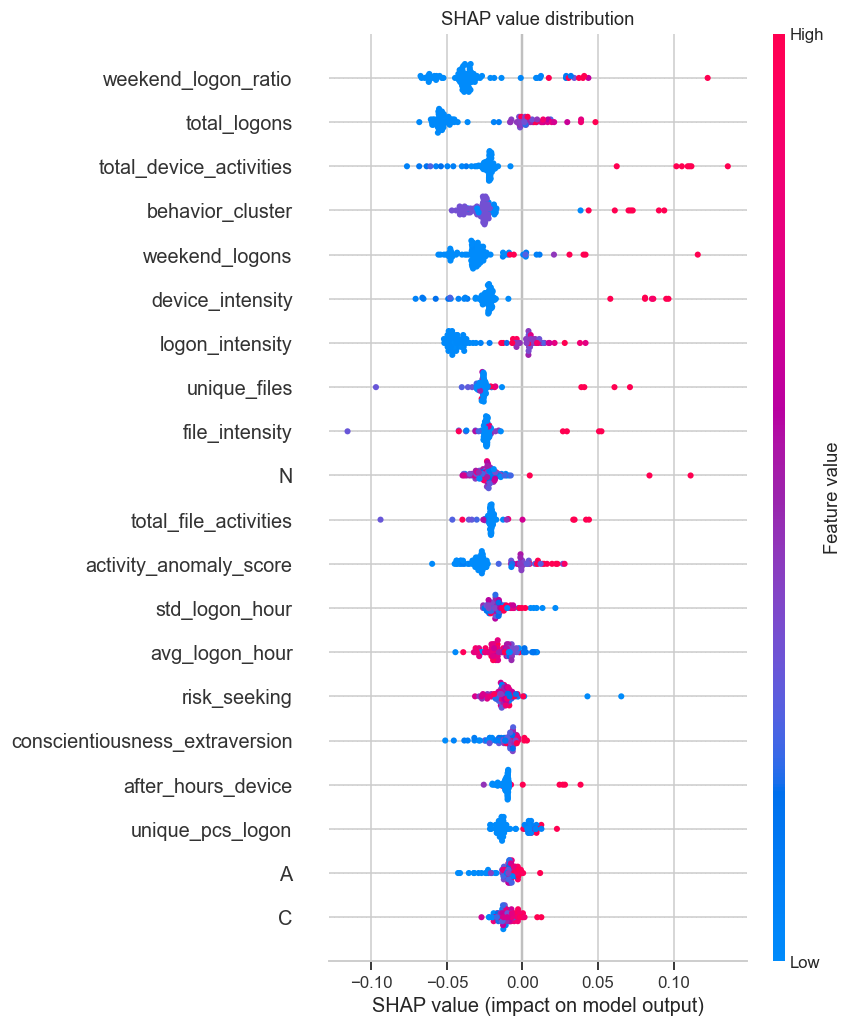

In [35]:
shap.summary_plot(sv, sample, show=False)
plt.title('SHAP value distribution')
plt.tight_layout()
plt.show()


**Read:** The SHAP ordering echoes the impurity importance, and the beeswarm shows the expected direction — high after-hours/weekend ratios, high intensity and high logon-hour variability push predictions toward 'anomaly'. Because the top drivers are interpretable behavioural quantities, an analyst can read a per-user explanation, which matters for acting on a flag.

## Temporal patterns: normal vs anomalous

The models lean on off-schedule behaviour, so we verify that directly. We compare the after-hours and weekend ratios and the logon hour between the two groups, with a t-test on each.


In [36]:
def group_compare(col):
    a = fe.loc[y == 1, col]
    n = fe.loc[y == 0, col]
    t, p = ttest_ind(n.dropna(), a.dropna())
    return {'feature': col, 'normal_mean': n.mean(), 'anomaly_mean': a.mean(),
            'difference': a.mean() - n.mean(), 'p_value': p}
temporal_summary = pd.DataFrame([group_compare(c) for c in
                                 ['after_hours_logon_ratio', 'weekend_logon_ratio', 'avg_logon_hour']])
temporal_summary.round(4)


,feature,normal_mean,anomaly_mean,difference,p_value
0,after_hours_logon_ratio,0.0888,0.1708,0.0820,0.0000
1,weekend_logon_ratio,0.0128,0.0694,0.0566,0.0000
2,avg_logon_hour,12.1034,11.8655,-0.2379,0.0065


/var/folders/sw/jvm_9vs95tj9mj54z576clt40000gn/T/ipykernel_51949/1434043343.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['normal', 'anomaly'], patch_artist=True)
/var/folders/sw/jvm_9vs95tj9mj54z576clt40000gn/T/ipykernel_51949/1434043343.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['normal', 'anomaly'], patch_artist=True)
/var/folders/sw/jvm_9vs95tj9mj54z576clt40000gn/T/ipykernel_51949/1434043343.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['normal', 'anomaly'], patch_artist=True)


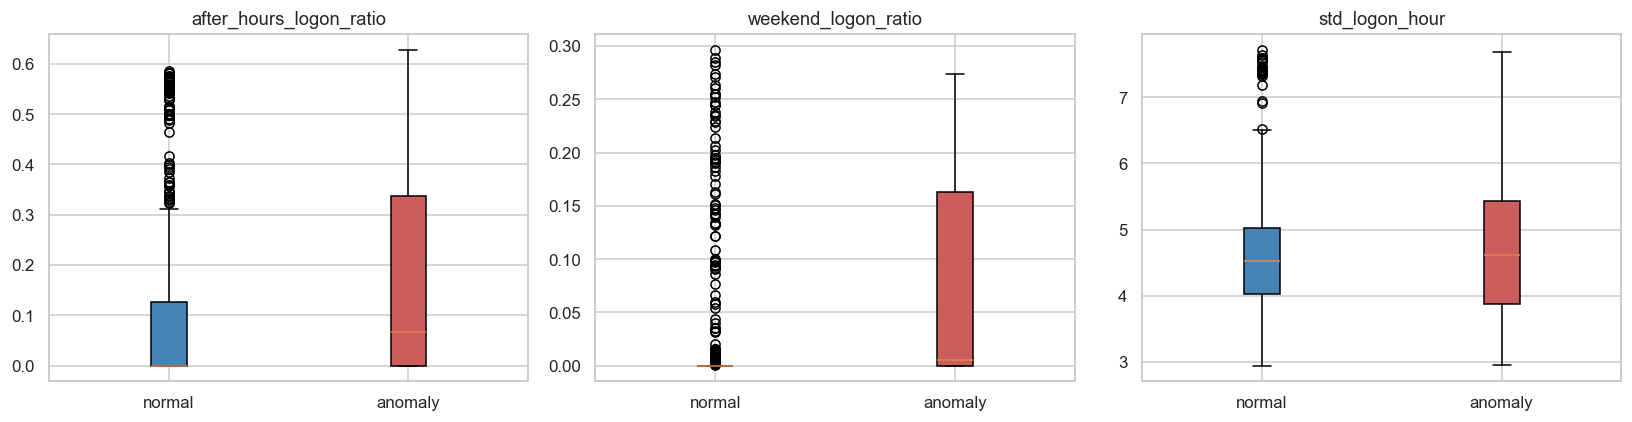

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['after_hours_logon_ratio', 'weekend_logon_ratio', 'std_logon_hour']):
    data = [fe.loc[y == 0, col], fe.loc[y == 1, col]]
    bp = ax.boxplot(data, labels=['normal', 'anomaly'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('indianred')
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Read:** Anomalous users show roughly twice the after-hours ratio and several times the weekend ratio of normal users, with a highly significant t-test on both. The behavioural gap the models exploit is real and matches the CERT indicators — after-hours and weekend activity are the clearest discriminators.

## Psychometric differences

Do personality traits separate the groups? We test each Big Five trait with a t-test and report the effect size (Cohen's d) — significance alone can mislead, so d tells us whether any difference is practically meaningful.


In [38]:
def trait_compare(trait):
    a = fe.loc[y == 1, trait]
    n = fe.loc[y == 0, trait]
    t, p = ttest_ind(n, a)
    pooled = np.sqrt(((len(n) - 1) * n.var() + (len(a) - 1) * a.var()) / (len(n) + len(a) - 2))
    d = (a.mean() - n.mean()) / pooled if pooled else 0
    return {'trait': trait, 'normal_mean': n.mean(), 'anomaly_mean': a.mean(),
            'p_value': p, 'cohens_d': d}
psych_summary = pd.DataFrame([trait_compare(t) for t in ['O', 'C', 'E', 'A', 'N']])
psych_summary.round(4)


,trait,normal_mean,anomaly_mean,p_value,cohens_d
0,O,33.5659,32.9222,0.5780,-0.0615
1,C,31.4538,32.3111,0.4765,0.0787
2,E,29.0297,29.8667,0.5003,0.0745
3,A,29.0264,28.7000,0.7902,-0.0294
4,N,29.4879,29.8111,0.5607,0.0643


**Read:** No Big Five trait differs significantly between the groups (all p > 0.05, all |d| < 0.2 — negligible effect). Personality does not separate anomalies in this dataset. The engineered psychometric interactions are worth keeping for the deep model, but the discriminative power clearly lives in *behaviour*, not personality — a useful negative result that focuses the rest of the project.

##  Model selection

We combine the CV metrics with an explicit weighting that reflects security priorities: recall and precision matter most (missing an insider is costly, but so is alert fatigue), then AUC and F1, with accuracy weighted least because it is inflated by the majority class.


In [39]:
weights = {'accuracy': 0.1, 'precision': 0.25, 'recall': 0.3, 'f1': 0.15, 'auc': 0.2}
weighted = (cv_table[list(weights)] * pd.Series(weights)).sum(axis=1).sort_values(ascending=False)
weighted.round(4)


XGBoost                0.7819
SVM                    0.7607
Random Forest          0.7519
Logistic Regression    0.6810
dtype: float64

**Read:** Under a recall-weighted rule the ranking rewards models that actually catch anomalies rather than those that merely score high accuracy. SVM and the tree models lead; Logistic Regression's strong recall keeps it competitive despite weak precision. No single model dominates every metric, which sets up the deep multi-input model in Weeks 6–7 as an attempt to improve recall without sacrificing precision.